# Modelling a circumbinary dust rim with HMC

This tutorial walks through parametric modelling of a circumbinary dust rim using
a chromatic model with an azmiuthally modulated Gaussian rim. For this we'll be using
the VLTI/PIONIER dataset of [Hillen et al. 2016](http://dx.doi.org/10.1051/0004-6361/201628125),
where they target the circumbinary disk surrounding the evolved post-AGB binary 
IRAS 08544-443.

First, let's import everything we will need.

In [1]:
# import pyoifits as oifits
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pyoifits as oifits
from mpl_toolkits.axes_grid1 import make_axes_locatable
# import ehtplot

from drpangloss.models import BinaryGaussianRimModel, OIData
from drpangloss._utils import img_get_sky_coordinates

## Loading data

The dataset consists of multiple OIFITS files. We'll be reading these in and
combining them into one consistent dataset, for which `pyoifits` provides a convenient
interface via the `+` addition operator. This `pyoifits` object can then readily
be wrapped into a `OIData` object which `drpangloss` uses to handle data. The PIONIER
data consists of squared visibilities ($V^2$) and closure phases ($\phi3$) for six
different wavelength channels. 

In [2]:
ddir = Path("../data/IRAS08544-4431_PIONIER/")

data_pyoifits = None
for oifits_file in ddir.glob("*.fits"):
    if data_pyoifits is None:
        data_pyoifits = oifits.open(oifits_file)
    else:
        data_pyoifits += oifits.open(oifits_file)

# Create a OIData object from the resulting pyofits object.
oidata = OIData(data_pyoifits)

### Quick plotting check of the loaded data.

Below, we extract some useful quantities to make some diagnostic plots of our data,
just to see if all data has been read in properly and if we can alreay glean something
about the target structure from the data. To have a good look at the spatial and 
chromatic structure of the target, we'll be plotting the $V^2$ data and $\phi3$ data
as a function of observed spatial frequency (using the longest baseline per closure
triangle for the $\phi3$ data), and color-coding everything by wavelength $\lambda$.

In [3]:
# Observed squared visibilities data per baseline.
obs_vis2 = oidata.vis
obs_d_vis2 = oidata.d_vis
obs_vis2_wavel = oidata.wavel  # Wavelength per observed squared visibility.
# Spatial frequencies per baseline.
obs_uf = oidata.u / oidata.wavel
obs_vf = oidata.v / oidata.wavel
obs_basef = jnp.hypot(obs_uf, obs_vf)  # Norm of spatial frequency.

# Observed closure phases per closure triangle.
obs_cp = oidata.phi
obs_d_cp = oidata.d_phi
obs_cp_wavel = obs_vis2_wavel[
    oidata.i_cps1
]  # Wavelength per observed closure phase.
# Max baseline norm for the baseline closure triangles.
obs_basemaxf = jnp.maximum(
    obs_basef[oidata.i_cps1],
    jnp.maximum(obs_basef[oidata.i_cps2], obs_basef[oidata.i_cps3]),
)

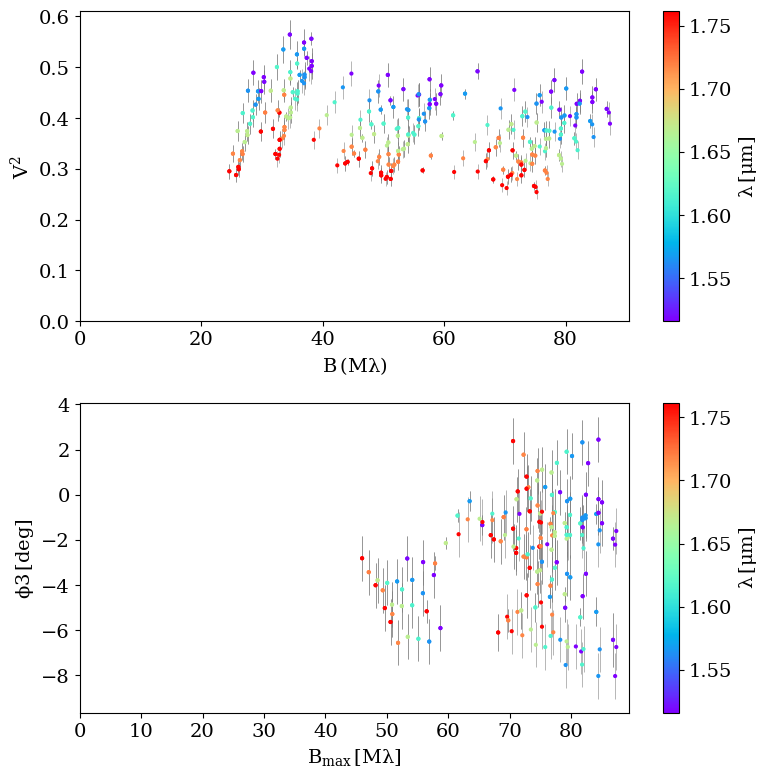

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8))

# Squared visibility data.
axes[0].errorbar(
    obs_basef / 1e6,
    obs_vis2,
    obs_d_vis2,
    fmt=",",
    elinewidth=0.4,
    ecolor="grey",
    zorder=-1,
)
sc1 = axes[0].scatter(
    obs_basef / 1e6, obs_vis2, c=obs_vis2_wavel * 1e6, s=4, cmap="rainbow"
)

# Closure phase data.
axes[1].errorbar(
    obs_basemaxf / 1e6,
    obs_cp,
    obs_d_cp,
    fmt=",",
    elinewidth=0.4,
    ecolor="grey",
    zorder=-1,
)
sc2 = axes[1].scatter(
    obs_basemaxf / 1e6, obs_cp, c=obs_cp_wavel * 1e6, s=4, cmap="rainbow"
)

fig.colorbar(sc1, ax=axes[0], label=r"$\lambda \, [\mathregular{\mu m}]$")
fig.colorbar(sc2, ax=axes[1], label=r"$\lambda \, [\mathregular{\mu m}]$")

axes[0].set_xlim(0)
axes[0].set_ylim(0)
axes[0].set_ylabel(r"$V^2$")
axes[0].set_xlabel(r"$B \, (\mathregular{M\lambda})$")

axes[1].set_xlim(0)
axes[1].set_ylabel(r"$\phi 3 \, [\mathregular{deg}]$")
axes[1].set_xlabel(r"$B_{\mathregular{max}} \, [\mathregular{M\lambda}]$")

plt.tight_layout()
plt.show()

We can also make a quick plot per baseline/triangle, so we can more clearly see trend
for the same baseline/triangle but across wavelengths.

In [5]:
# TODO: implement

As we can see, the visibilities show some Bessel-like oscillations around a $V^2$ plateau.
This is indicative of some ring-like structure surrounding a central un- or marginally-resolved
object (which in this case is the primary star). There is also clearly a chromatic effect
where the level of the plateau decreases at longer wavelengths, which indicates that at these
wavelengths the total flux of the central star contributes less. The $\phi3$ data are also
clearly non-zero, which indicates some asymmetry in the intensity of the distribution, either
due to the presence of the binary companion, an offset of the central star relative to 
the disk rim, or azimuthal modulations of the disk rim itself! We'll model these effects
below.


## Defining a chromatic circumbinary disk model

Below, we'll recreate the [Hillen et al. 2016](http://dx.doi.org/10.1051/0004-6361/201628125) model
used for the system. There are some differences though, including the use of spectral indices 
($d$ if $F_{\lambda} \propto (\lambda / \lambda_0)^d$) instead of blackbody temperatures 
to define the spectral behaviour. We also do not fit any chromaticity to the overresolved
background and secondary star.

The model consists of a chromatic point source for the primary, a chromatic azimuthally
modulated Gaussian disk rim and a grey companion point source and overresolved flux.
This model is implemented in the `BinaryGaussianRimModel` class.
Feel free to play around a little with the parameters and see how things change.

In [6]:
# Recreation of the Hillen et al. 2016 (A&A 588, L1) model. Differences include that the
# primary star is not in Rayleigh-Jeans regime (instead `si_p` is taken from a power-law
# fit to the synthetic H-band SED fit spectrum). `si_rim` (derived from the blackbody
# temperature found in the paper) has been corrected accordingly.
model_params = {
    "flux_p": 0.597,  # Total flux fraction of the primary.
    "dra_p": 0.0,  # Primary right ascension offset in milliarcseconds.
    "ddec_p": 0.0,  # Primary declination offset in milliarcseconds.
    "si_p": -3.166,  # Spectral index of the primary.
    "flux_s": 0.039,  # Secondary flux fraction.
    "dra_s": -0.5,  # Secondary right ascension offset in milliarcseconds.
    "ddec_s": -0.7,  # Secondary declination offset in milliarcseconds.
    "diam_rim": 14.15,  # Diameter of the rim in milliarcseconds.
    "fwhm_rim": 3.233,  # Gaussian FWHM of the rim in milliarcseconds.
    "inc_rim": 19.0,  # Inclination of the rim in degrees.
    "pa_rim": 6.0,  # Position angle of the rim in degrees.
    "si_rim": 3.6,  # Rim spectral index (from paper T_bb & modified for 'si_p' value).
    "flux_bkg": 0.155,  # Overresolved background flux fraction.
    "az_amps": [
        0.43011627,
        0.2745906,
    ],  # 1st & 2nd rim azimuthal modulation amplitudes (the paper worked with equivalent coefficients).
    "az_phis": [
        35.537678,
        50.245735,
    ],  # 1st & 2nd rim azimuthal modulation offset angles relative to 'pa_rim' in degrees.
    "wave0": 1.65e-6,  # Wavelength at which the flux fractions are defined in meter (not a free parameter).
}

model = BinaryGaussianRimModel(**model_params)

### Visualising the model morphology

The model also includes a model function to calculate an image of the modelled Gaussian 
rim. Note that this is purely for display and visual inspection purposes though. For this
model, the image is not actually used to calculate the predicted model observables (which
in this case are fully analytical).

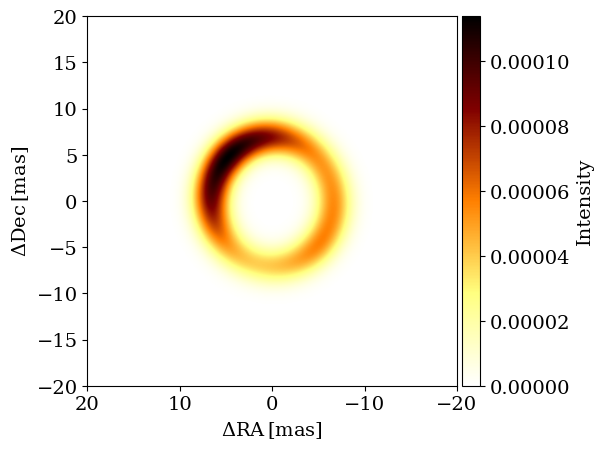

In [9]:
npix = 200  # Number of pixels along the field-of-view.
ps = 0.2  # Pixelscale in milliarcseconds.
fov = npix * ps

# Get an image of the rim.
rim_img = model.get_img(npix=400, ps=0.1)

# Get the coordinates.
xcoord, ycoord = img_get_sky_coordinates(rim_img, ps=ps)

fig, ax = plt.subplots(1, 1)
# Plot image.
im = ax.imshow(
    rim_img,
    extent=(
        fov / 2,
        -fov / 2,
        -fov / 2,
        fov / 2,
    ),
    cmap="afmhot_r",
)

# Add colorbar to the side.
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im, cax=cax, label="Intensity")

ax.set_xlabel(r"$\Delta \mathregular{RA} \, \mathregular{[mas]}$")
ax.set_ylabel(r"$\Delta \mathregular{Dec} \, \mathregular{[mas]}$")

plt.show()

In [ ]:
%timeit rim_img = model.get_img(npix=400, ps=0.1)

### Visualising the predicted model observables

Let's see what our current model predicts for the $V^2$ and $\phi3$ observables, and how
it holds up against the observed data. You'll see that we're not quite there yet
in terms of having a good fit to the data.

In [ ]:
# TODO: implement

### Timing test

We can do a quick timing test to see how fast `drpangloss`' data likelihood manages to
evaluate on this model, which will give us a good idea of the computing budget we have
available to us when running our inference algorithms. We use JAX's JIT to compile the model's 
predicted observables computation, and time with plenty of repeats and `block_until_ready()` 
(the latter accounting for JAX's asynchronous dispatch) to get rid of the JIT overhead.

For comparison, let's also look at the evaluation time without using JIT compilation. As you
can see, JAX's JIT-compilation can speed up our model evaluations dramatically! This
means we can easily run large amounts of likelihood evaluations in our inference algorithms.

In [ ]:
# Defining a JIT-ed version of the model evaluation.
model_eval_jit = jax.jit(lambda oidata, model: oidata.model(model))

print("\nTiming for JIT-ed version:\n" + "=" * 32)
%timeit -n 2000 -r 10 model_eval_jit(oidata, model).block_until_ready()
print("=" * 32 + "\n")

print("\nTiming for non-JIT-ed version:\n" + "=" * 32)
%timeit -n 50 -r 10 oidata.model(model).block_until_ready()
print("=" * 32)

## Running inference algorithms

Here we'll actually try to finetune our model using some of the powerful elements in
the wider JAX toolbox.

In [ ]:
# TODO: